# Dependence-character transitions: exploratory scout

Question: does SPI–SPI track an independently defined change beyond signed/absolute Pearson and the vector of all SPI means? These are separate comparisons. No advantage is presumed; this notebook keeps physical checks, failed candidates and the compositional control separate.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'configs/analysis/dependence-transition-261005.yaml').is_file())
RESULTS = ROOT / 'results/order-parameter-inference/dependence-transition-261005'
def show(relative):
    display(Image(filename=str(RESULTS / relative), width=1100))

## Physical candidates: generalized synchronization

A response can become a reproducible nonlinear function of a chaotic drive without their signals becoming equal. The largest conditional response Lyapunov exponent measures whether response perturbations grow or contract. An independently initialized auxiliary response checks convergence, but is **excluded** from the observed MTS. Ground truth is measured on a disjoint, longer future trajectory.

The sweep compares a Rössler pair, Rössler driving Lorenz, and driven logistic modules. For the flows, $M=N=6$ observed states; the auxiliary and tangent variables are diagnostic only. The first figure uses **11 cheap probes, not p90**; four seeds fit PC1 and four evaluate it. Shading in the first column spans the two pooled reference-half estimates, not a confidence interval.

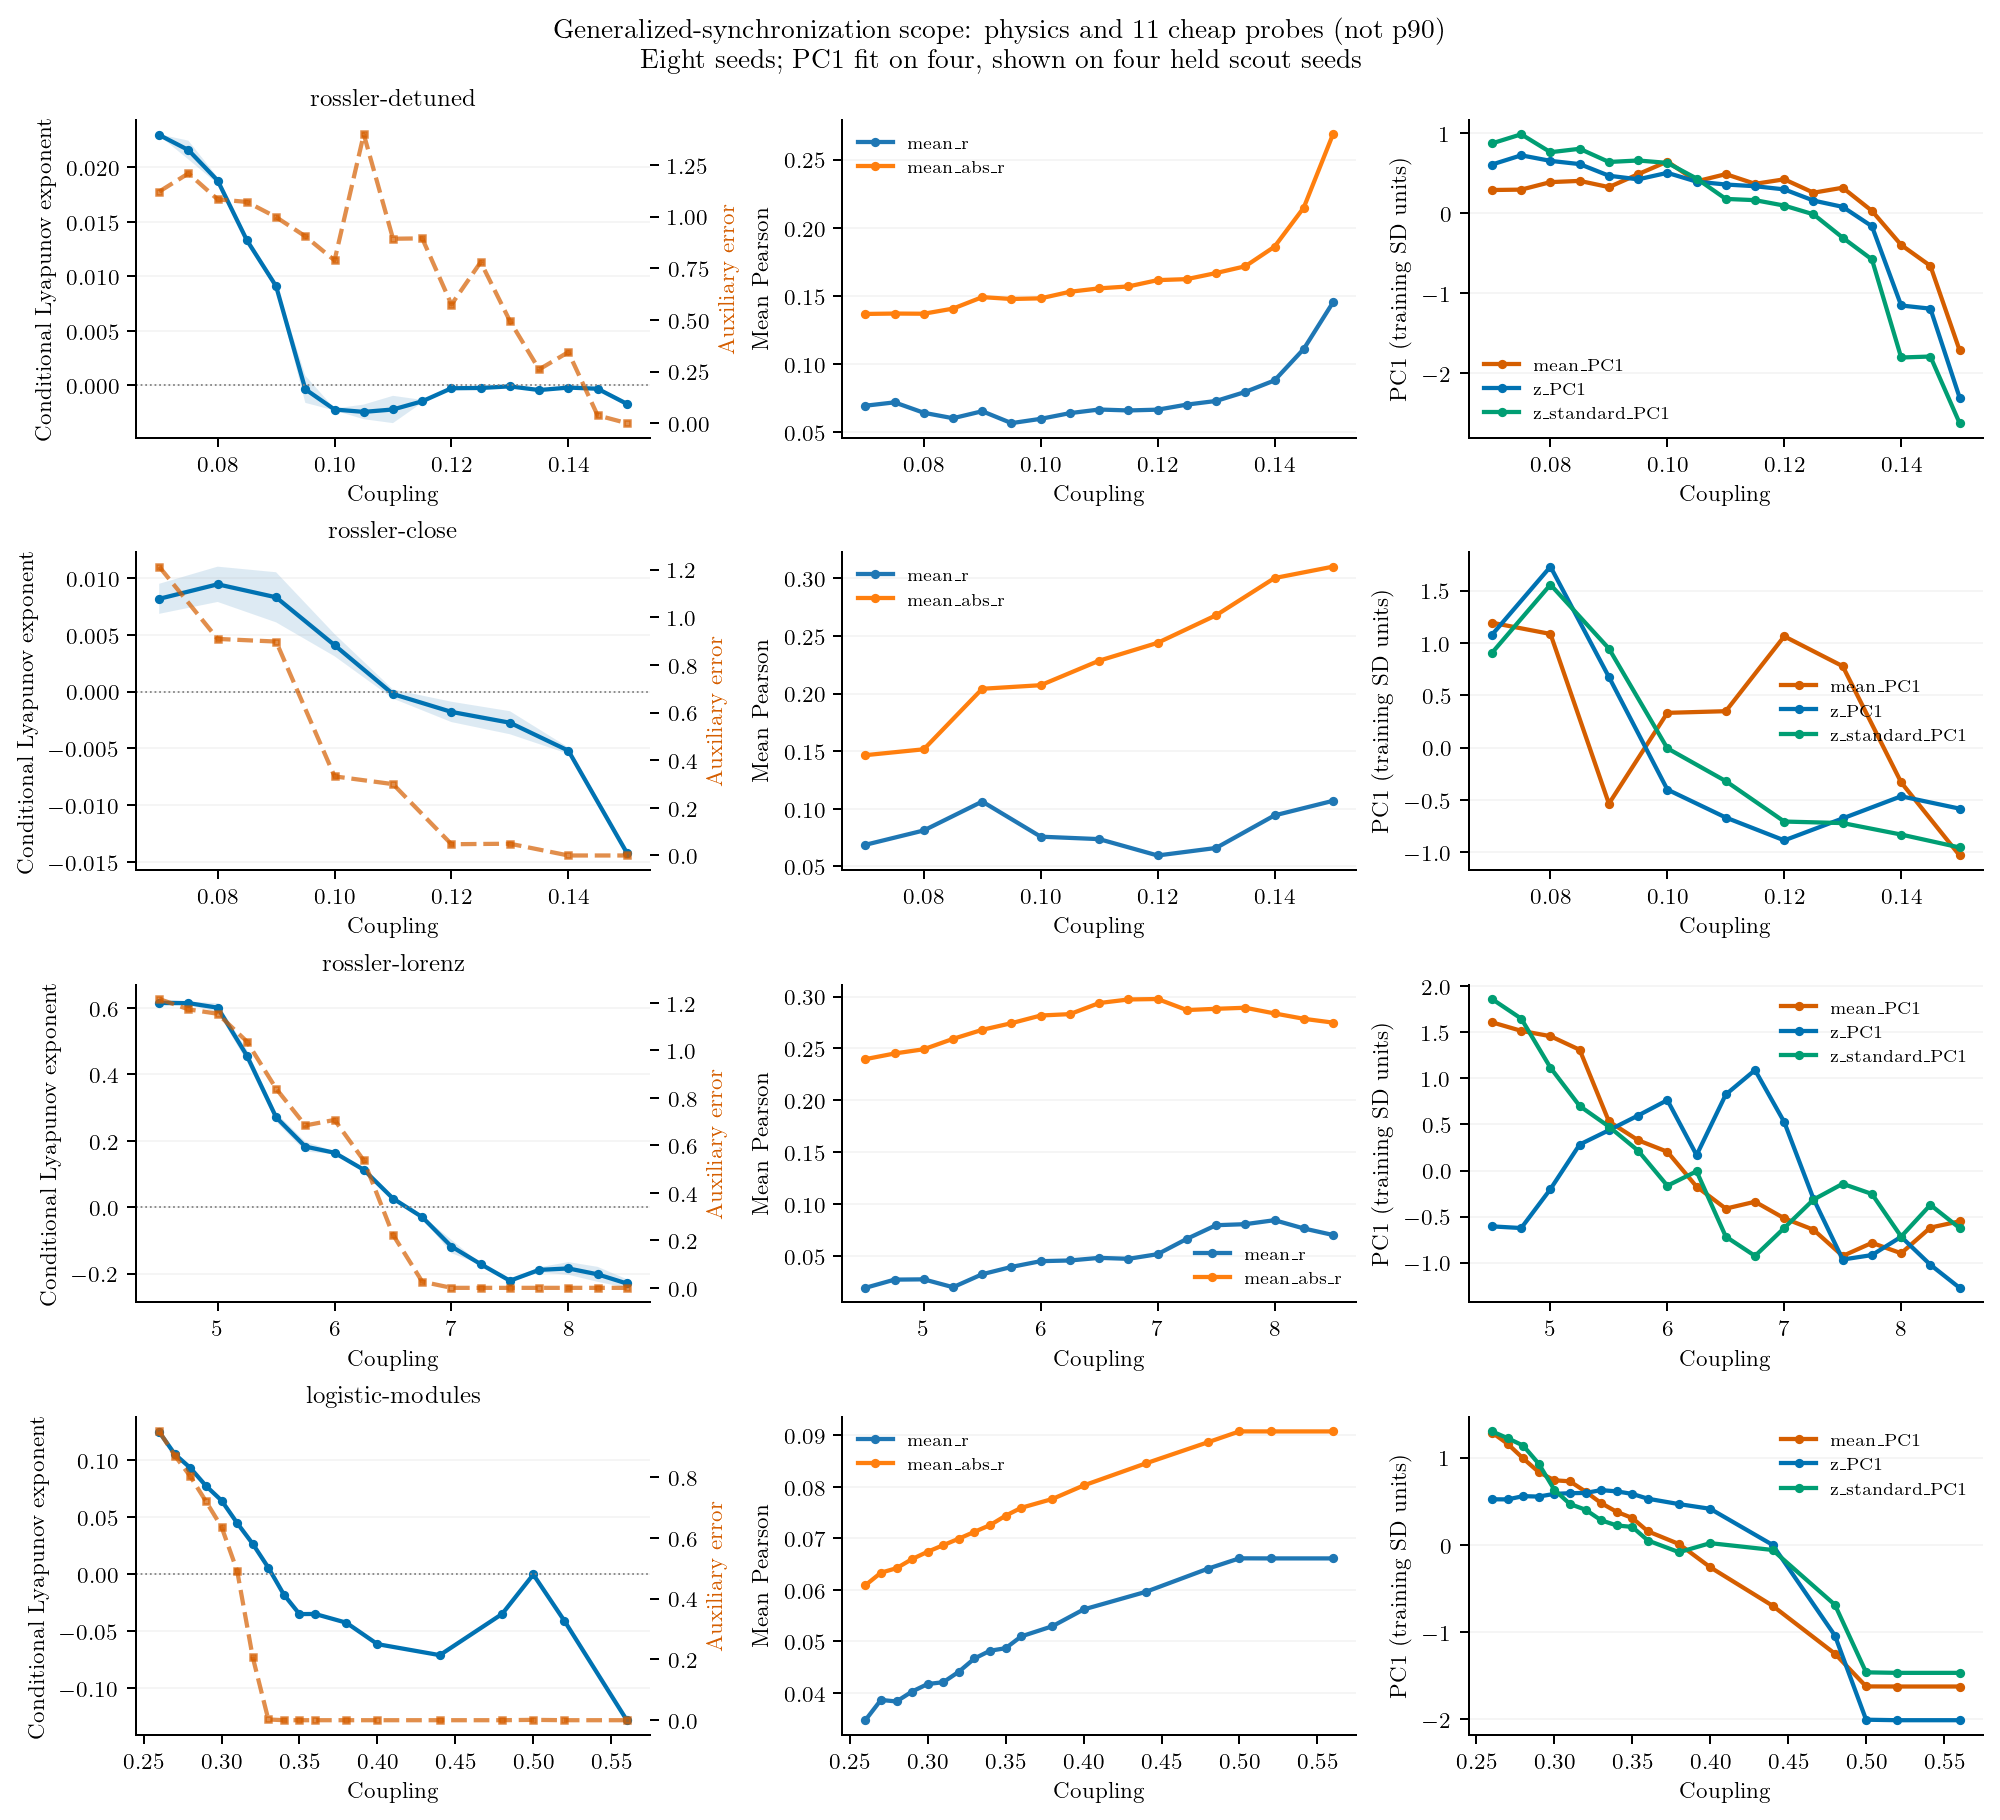

In [2]:
show('physics/physics-and-probes.png')

Longer burn/reference and half-step checks support advancing close-frequency Rössler and Rössler–Lorenz. Detuned Rössler retains conflicting auxiliary/CLE evidence. Logistic auxiliary copies sometimes coalesce numerically while the CLE remains positive: zero auxiliary error alone is not proof of stable synchronization. Cheap-probe comparisons do not establish a general mean-baseline failure.

## Fixed local sweeps: full p90

Two systems × 13 controls × 16 fresh initial-condition seeds: 416 recordings, $M=N=6$, $T=1000$. Eight seeds fit each coordinate; eight evaluate it. Both centered and standardized z-PC1 are reported. Stronger mean baselines include a training-selected individual mean and full-vector ridge/RBF with seed-grouped training-only tuning. No component or narrower interval is selected using evaluation outcomes.

**Result:** SPI–SPI improves on mean signed Pearson here, but no advantage over the stronger mean-vector baselines is established. Close Rössler gives held $|\rho|=.855$ for z-PC1, $.638$ for mean Pearson, $.835$ for mean-PC1 and $.874$ for a supervised mean-vector readout. The last comparison tests information availability, not like-for-like unsupervised performance. Rössler–Lorenz is not a clean sharp z transition. All comparisons use the same eligible records (102/104 and 104/104); two close-Rössler rows exceed the fixed 5% missing-z gate.

Sharpness is separate from correlation: close-Rössler z-PC1 has change-concentration width $.0287$ versus $.0328$ for mean-PC1, but the selected mean is $.0283$ and uncertainty overlaps. No unique sharpness advantage is established. These results concern control sweeps, not within-control fluctuation recovery.

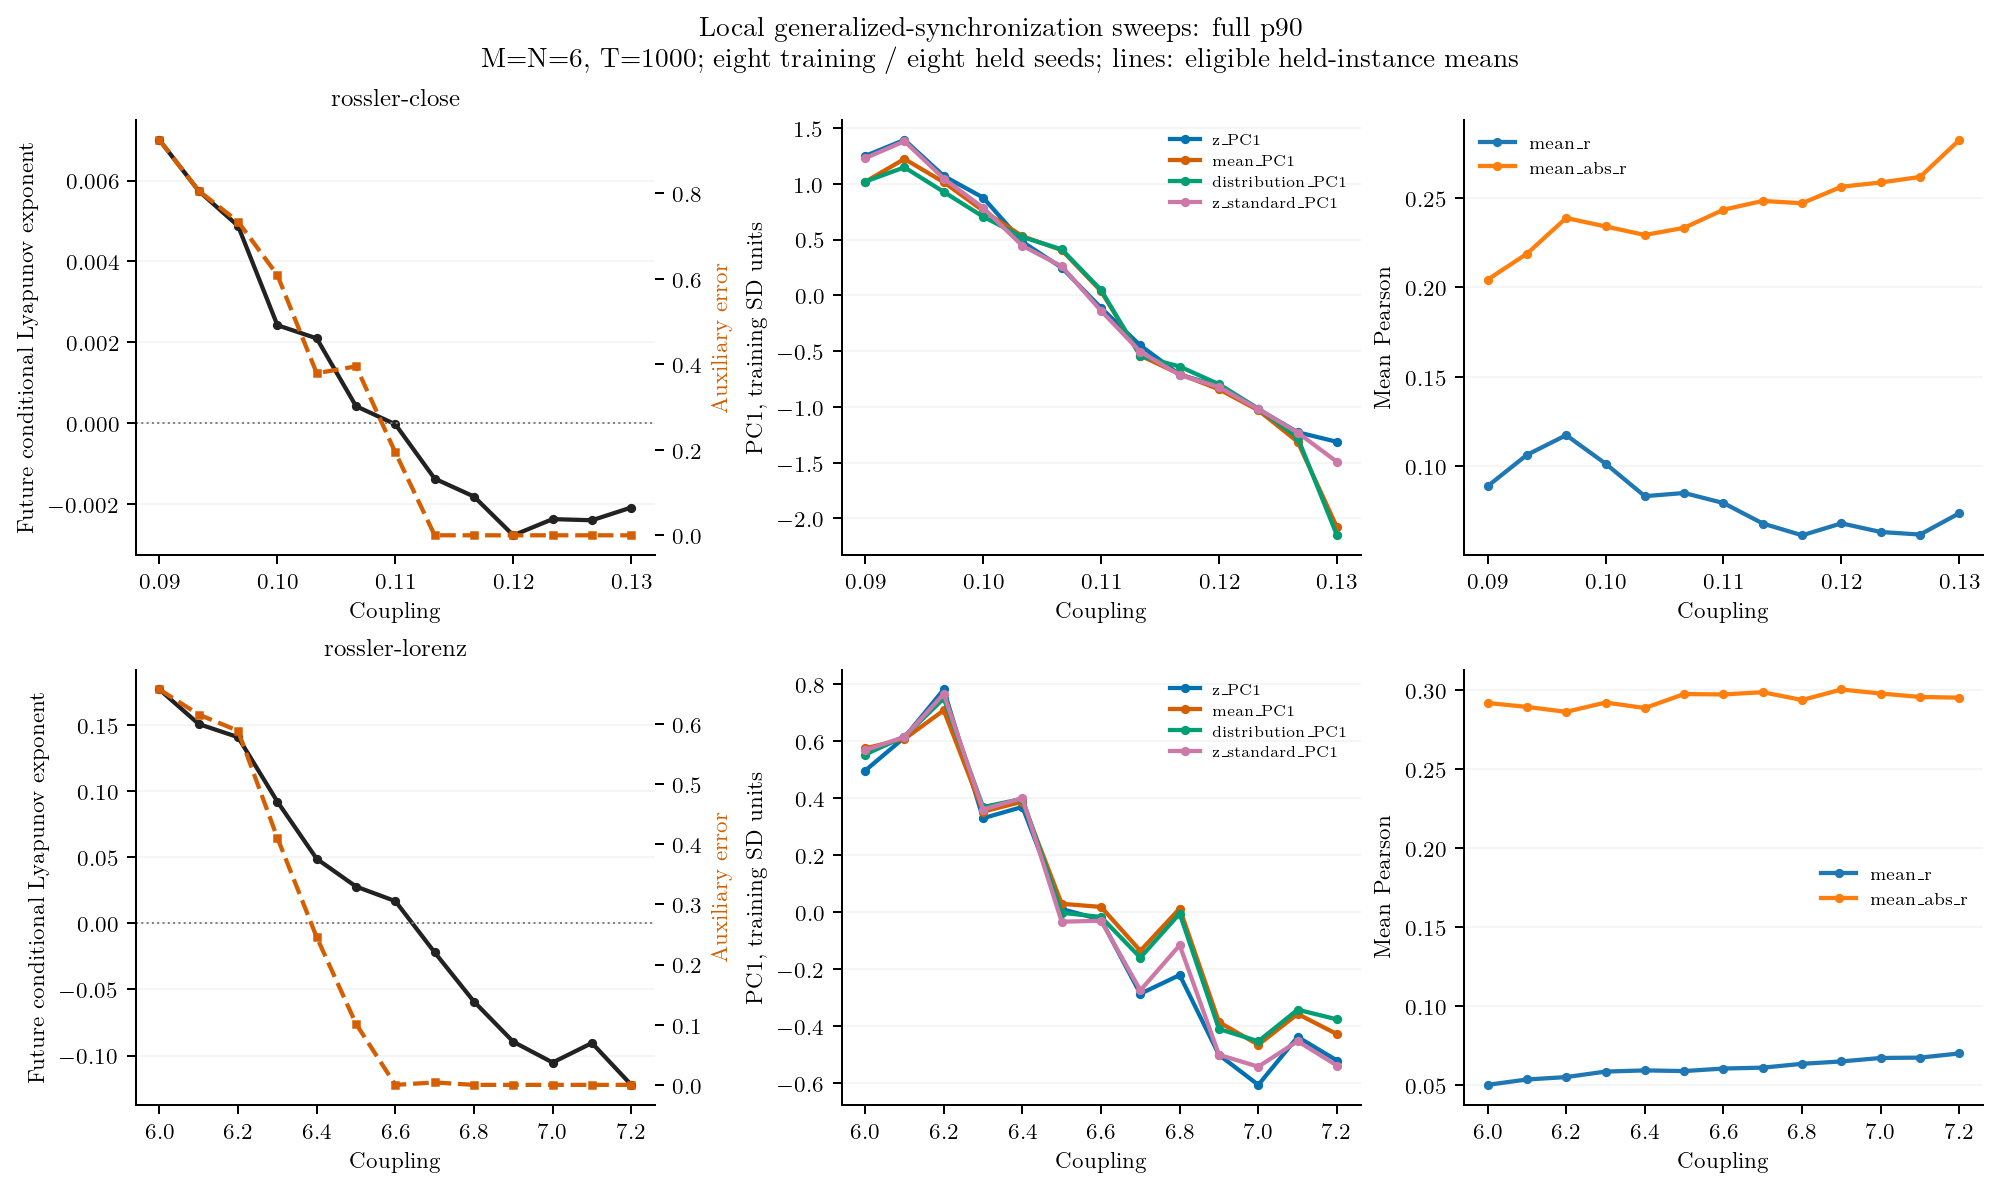

,system,method,n,held_abs_rho
0,rossler-close,z_PC1,102,0.855
1,rossler-close,z_standard_PC1,102,0.851
2,rossler-close,mean_PC1,102,0.835
3,rossler-close,distribution_PC1,102,0.832
4,rossler-close,selected_mean,102,0.845
5,rossler-close,mean_ridge,102,0.868
6,rossler-close,mean_RBF,102,0.874
7,rossler-close,mean_r,102,0.638
8,rossler-close,mean_abs_r,102,0.572
9,rossler-lorenz,z_PC1,104,0.518


In [3]:
if (RESULTS / 'p90/p90-comparison.png').is_file():
    show('p90/p90-comparison.png')
    display(pd.read_csv(RESULTS / 'p90/metrics.csv')[['system', 'method', 'n', 'held_abs_rho']].round(3))
else:
    print('Full-p90 extraction/analysis pending; no full-catalogue advantage claimed.')

## Analytic compositional control: joint extremes

Eight independent bivariate Student-t modules give $M=N=16$. Swap which links combine correlation $\rho=0.1$ or $0.2$ with degrees of freedom $\nu=3$ or $30$, preserving both multisets. Because $I(\rho,\nu)=-\tfrac12\log(1-\rho^2)+c(\nu)$, population mean Pearson, Kendall and MI stay fixed while their pairwise alignment changes. Other SPI means are not assumed fixed.

Ground truth is average upper-tail dependence, $\lambda_U=2t_{\nu+1}(-\sqrt{(\nu+1)(1-\rho)/(1+\rho)})$. This is a known dependence quantity in an engineered stochastic construction, **not a bifurcation**. Nu=3 has finite variance but infinite fourth moment, so finite-sample fluctuations matter.

In [4]:
display(pd.read_csv(RESULTS / 'tail-alignment/population.csv').round(6))
display(pd.read_csv(RESULTS / 'tail-alignment/metrics.csv').round(3))

,swaps,Q_tail,mean_r,mean_tau,mean_MI,z_r_MI
0,0,0.004826,0.01,0.006399,0.00228,0.756106
1,1,0.005101,0.01,0.006399,0.00228,0.802539
2,2,0.005377,0.01,0.006399,0.00228,0.846429
3,3,0.005652,0.01,0.006399,0.00228,0.888153
4,4,0.005928,0.01,0.006399,0.00228,0.928002


,method,held_abs_rho,evr
0,mean_PC1,0.018,0.680
1,z_PC1,0.288,0.789
2,z_standard_PC1,0.404,0.511
3,mean_Pearson,0.008,NaN
4,mean_Spearman,0.012,NaN
5,mean_Kendall,0.006,NaN
6,mean_KSG_MI,0.073,NaN
7,prespecified_z_Pearson_MI,0.271,NaN


The preceding estimates use four focused probes, $T=1000$, 32 training and 32 held seeds per level. The p90 extension uses these same 320 records and is therefore exploratory—not fresh confirmation after selecting a favorable toy.

In [5]:
if (RESULTS / 'tail-alignment/p90/p90-tail-comparison.png').is_file():
    show('tail-alignment/p90/p90-tail-comparison.png')
    display(pd.read_csv(RESULTS / 'tail-alignment/p90/metrics.csv').round(3))
else:
    print('Tail-control p90 extraction/analysis pending.')

Tail-control p90 extraction/analysis pending.


[Protocol, equations, sources, failures and reproduction](../../docs/research/order-parameter-benchmarks/dependence-transition-261005.md). Existing polished benchmark notebooks are unchanged.